In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import rfft, rfftfreq, fft, fftfreq
from scipy.io import wavfile
from scipy.signal import remez, lfilter

In [ ]:
t = 2 * np.pi * np.linspace(-0.2, 0.2, 200)
s_M = 3 * np.cos(2 * np.pi * t) - np.sin(6 * np.pi * t + np.pi / 4)

In [ ]:
w_0 = 10
s_AM = s_M * np.cos(2 * np.pi * w_0 * t)

Модулирующий сигнал:

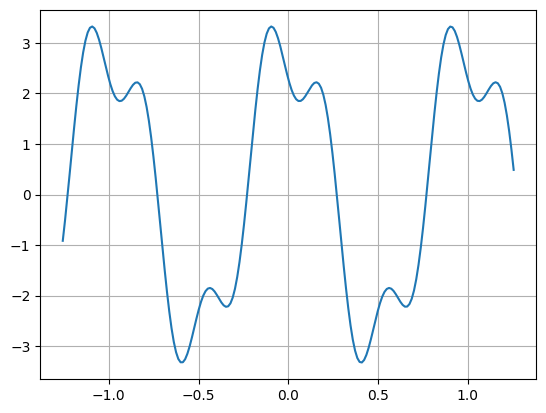

In [ ]:
plt.plot(t, s_M)
plt.grid()

Модулированный сигнал. Видно, что его огибающая соответствует **модулю** исходного сигнала:

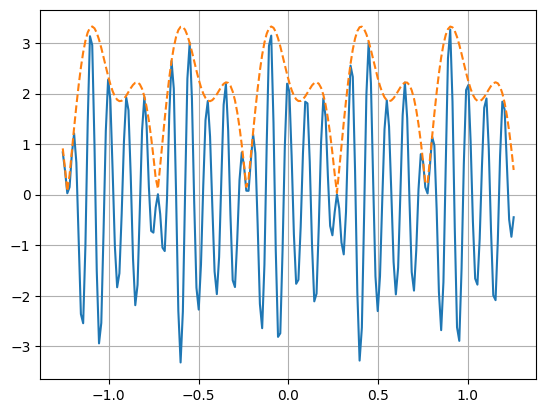

In [ ]:
plt.plot(t, s_AM, t, abs(s_M), '--',)
plt.grid()

Модулированный сигнал с добавлением константы модулирующему сигналу:

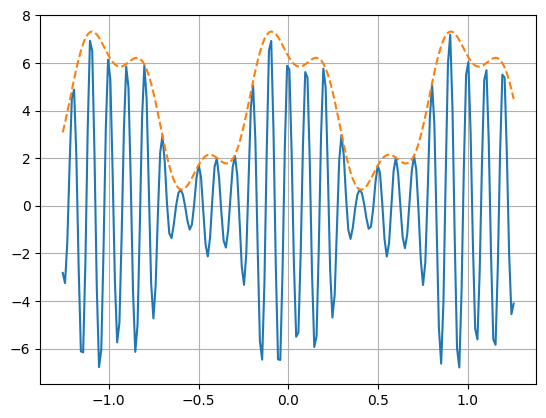

In [ ]:
s_AM_2 = (4 + s_M) * np.cos(2 * np.pi * w_0 * t)
plt.plot(t, s_AM_2, t, 4 + s_M, '--')
plt.grid()

Рассмотрим случай, когда модулирующий сигнал является гармоническим

In [ ]:
def signal_am(amp=1.0, km=0.25, fc=10.0, fs=2.0, period=100):
    """
    amp : float
        Амплитуда модулиующего сигнала
    km : float
        Коэффициент модуляции 0 <= km < 1 (глубина модуляции)
    fc : float
        Несущая частота
    fs : float
        Частота исходного сигнала
    period : integer
        Период сигнала в отсчетах
    """
    tt = 2.0 * np.pi * np.linspace(0, 1, period)
    return amp * (1 + km * np.cos(fs * tt)) * np.cos(fc * tt)

Посмотрим, как меняется АМ-сигнал в зависимости от несущей частоты. При изменении несущей частоты происходит смещение всего спектра по частоте.

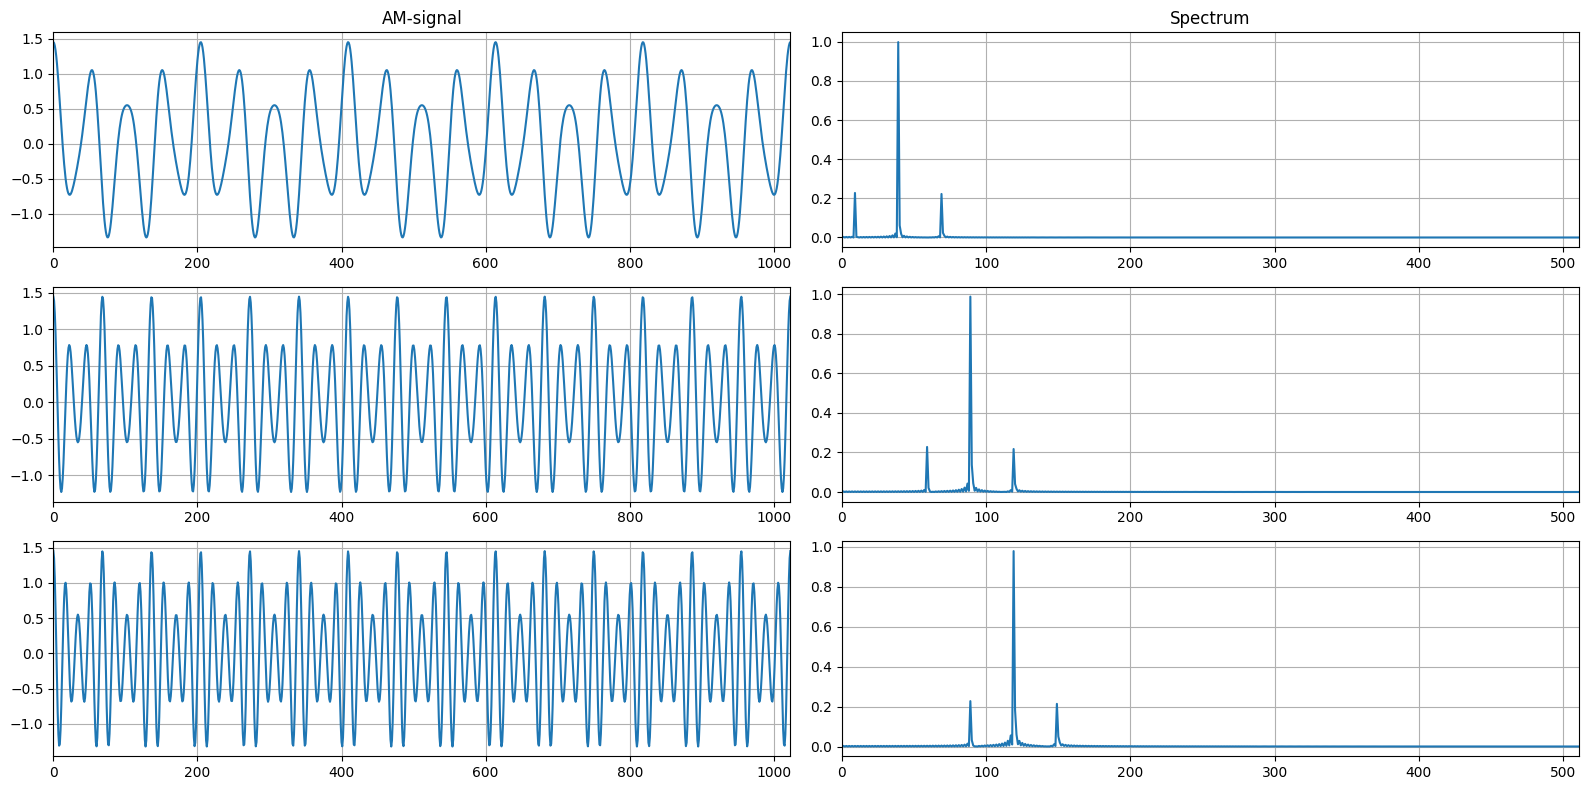

In [ ]:
N = 1024

fs = 15             # Модулирующая частота
fc = [20, 45, 60]   # Несущая частота

sig = [signal_am(amp=1.0, km=0.45, fc=i, fs=fs, period=N) for i in fc]
sft = np.abs(rfft(sig, axis=1)) / N / 0.5

plt.figure(figsize=(16, 8))
for i, freq in enumerate(fc):
    plt.subplot(len(fc), 2, 2*i+1)
    if i == 0:
        plt.title('AM-signal')
    plt.plot(sig[i])
    plt.xlim([0, N-1])
    plt.grid(True)

    plt.subplot(len(fc), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum')
    plt.plot(sft[i])
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

Что получится при изменении частоты модулирующего колебания? Пропорционально изменится ширина спектра модулированного колебания:

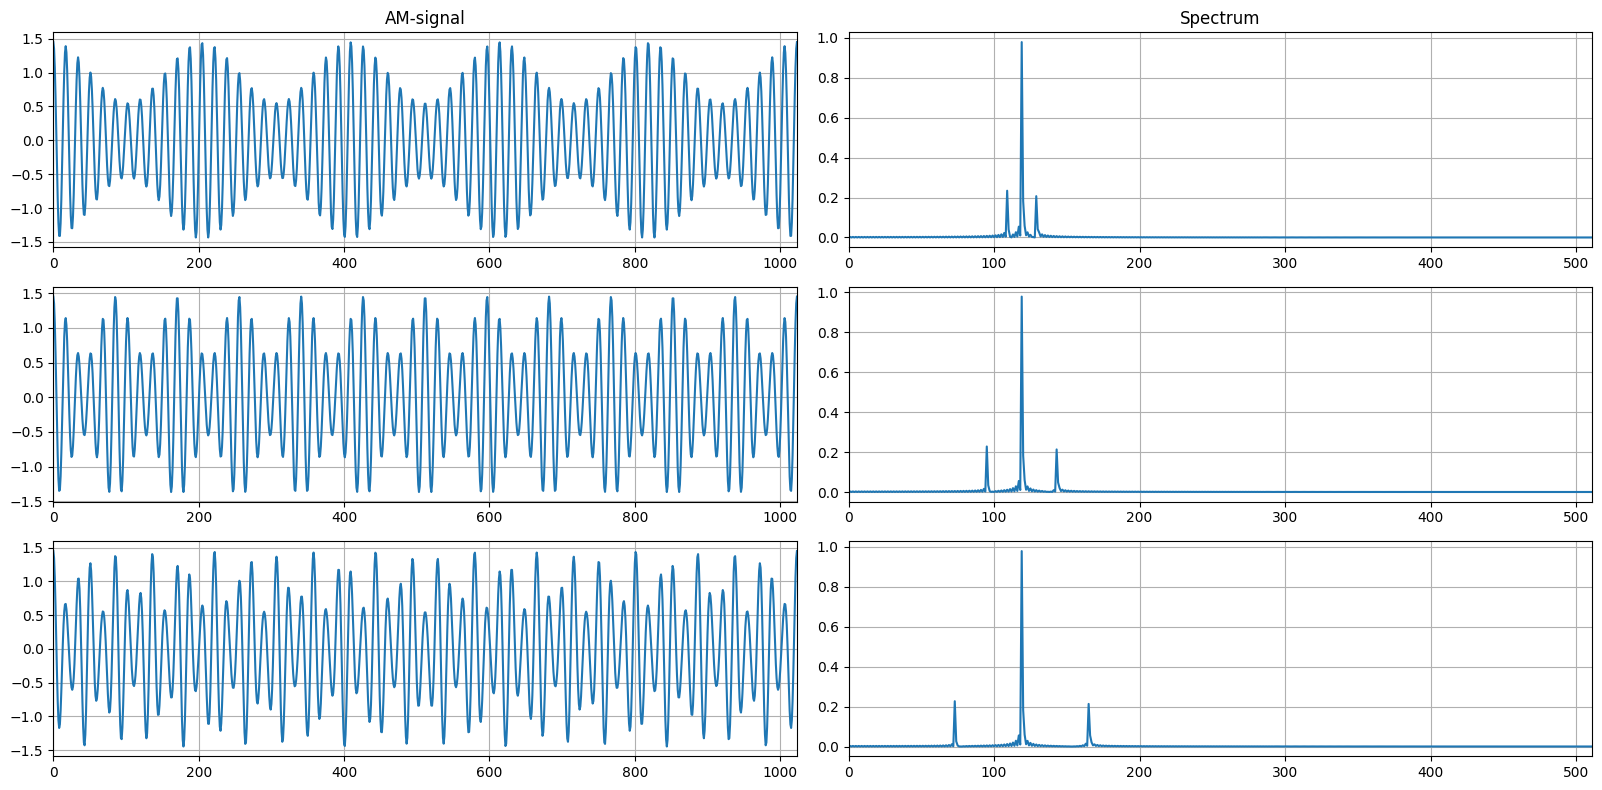

In [ ]:
N = 1024

fs = [5, 12, 23]    # Модулирующая частота
fс = 60             # Несущая

sig = [signal_am(amp=1.0, km=0.45, fc=fс, fs=i, period=N) for i in fs]

sft = np.abs(rfft(sig, axis=1)) / N / 0.5

plt.figure(figsize=(16, 8))
for i, freq in enumerate(fs):
    plt.subplot(len(fc), 2, 2*i+1)
    if i == 0:
        plt.title('AM-signal')
    plt.plot(sig[i])
    plt.xlim([0, N-1])
    plt.grid(True)

    plt.subplot(len(fs), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum')
    plt.plot(sft[i])
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

При изменении глубины модуляции будут меняться амплитуды боковых частот:

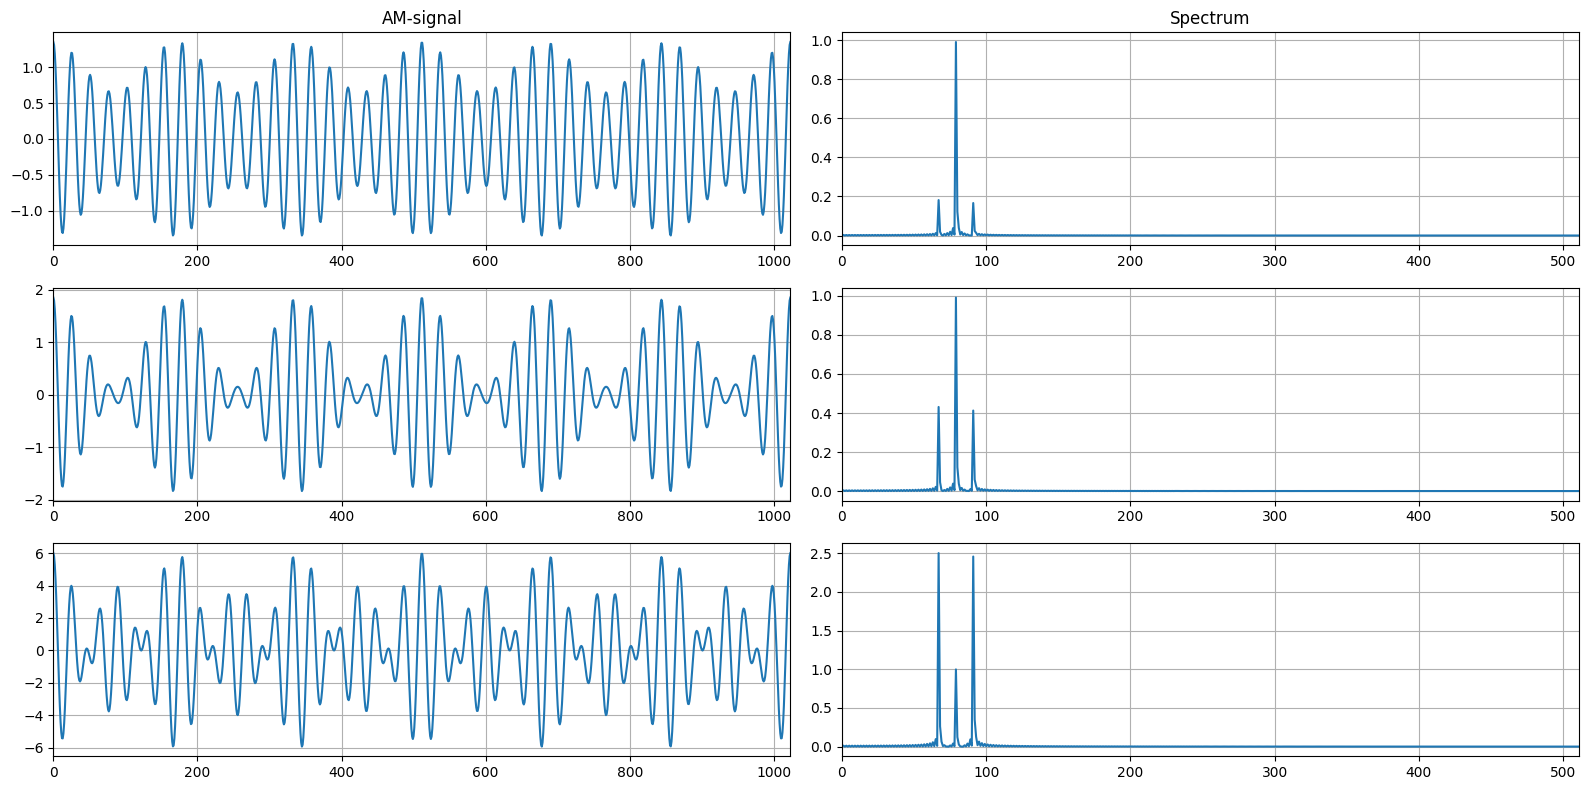

In [ ]:
N = 1024

fs = 6                  # Модулирующая частота
fс = 40                 # Несущая частота
km = [0.35, 0.85, 5]    # коэффициент (глубина) модуляции

sig = [signal_am(amp=1.0, km=i, fc=fс, fs=fs, period=N) for i in km]

sft = np.abs(rfft(sig, axis=1)) / N / 0.5

plt.figure(figsize=(16, 8))
for i, freq in enumerate(km):
    plt.subplot(len(km), 2, 2*i+1)
    if i == 0:
        plt.title('AM-signal')
    plt.plot(sig[i])
    plt.xlim([0, N-1])
    plt.grid(True)

    plt.subplot(len(km), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum')
    plt.plot(sft[i])
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

Посмотрим, как работает амплитудная модуляция и демодуляция на примере

In [ ]:
import os

if not os.path.exists('105977__wcfl10__favorite-station.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/105977__wcfl10__favorite-station.wav

--2025-03-31 18:58:28--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/105977__wcfl10__favorite-station.wav
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/105977__wcfl10__favorite-station.wav [following]
--2025-03-31 18:58:28--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/105977__wcfl10__favorite-station.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 247938 (242K) [audio/wav]
Saving to: ‘105977__wcfl10__favorite-station.wav’

105977__wcfl10__fav 100%[===================>] 242.13K  --.-KB/s    in 0.02s   

2025-03-31 18:58:28

In [ ]:
from IPython.display import Audio

Audio('105977__wcfl10__favorite-station.wav')

In [ ]:
fs, mod_signal = wavfile.read('105977__wcfl10__favorite-station.wav')

tt = np.linspace(0.0, len(mod_signal) / fs, len(mod_signal), endpoint=False)

T = 1.0 / fs
N = len(mod_signal)

# спектр сигнала
yf = fft(mod_signal)
xf = fftfreq(N, T)

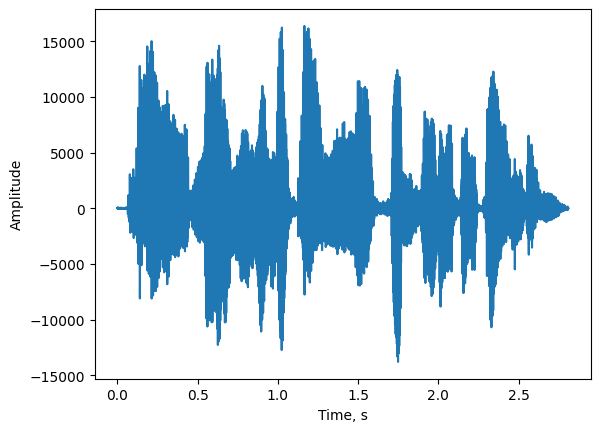

In [ ]:
plt.plot(tt, mod_signal)
plt.xlabel("Time, s")
plt.ylabel("Amplitude")
plt.show()

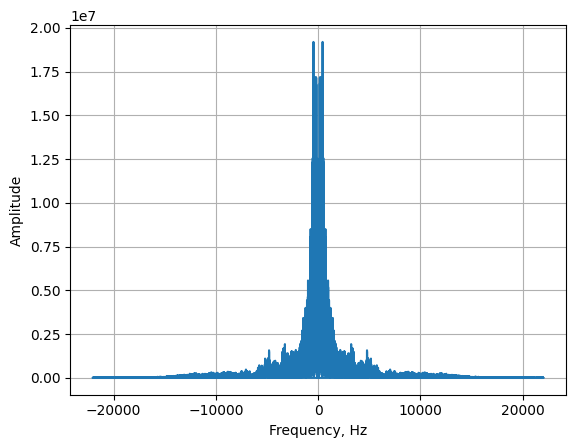

In [ ]:
plt.plot(xf, np.abs(yf))
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Задаем несущую частоту:

In [ ]:
f_carrier = 10000

carrier_wave = np.cos(2.0 * np.pi * f_carrier * tt)

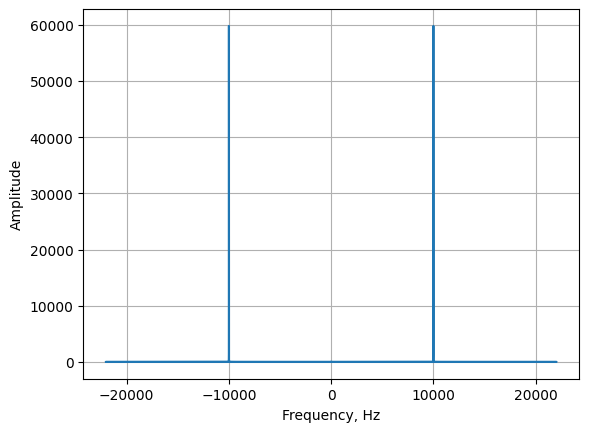

In [ ]:
# спектр несущей
yf_am = fft(carrier_wave)
xf = fftfreq(N, T)

plt.plot(xf, np.abs(yf_am))
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Получаем модулированный сигнал:

In [ ]:
a_modulated_signal = mod_signal * carrier_wave

In [ ]:
wavfile.write("a_modulated_signal.wav", fs, a_modulated_signal.astype(np.int16))

In [ ]:
Audio('a_modulated_signal.wav')

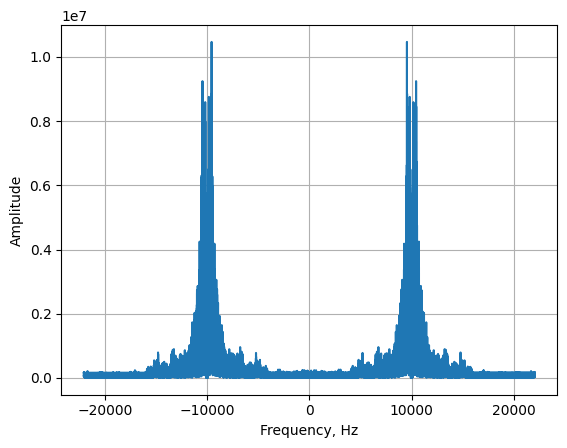

In [ ]:
# спектр модулированного сигнала
yf_am = fft(a_modulated_signal)
xf = fftfreq(N, T)

plt.plot(xf, np.abs(yf_am))
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [ ]:
demodulated_signal = a_modulated_signal * carrier_wave

In [ ]:
wavfile.write("demodulated_signal.wav", fs, demodulated_signal.astype(np.int16))

In [ ]:
Audio('demodulated_signal.wav')

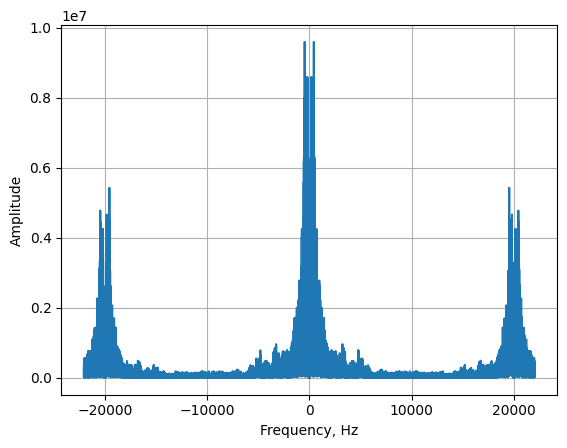

In [ ]:
# спектр демодулированного сигнала
yf_am = fft(demodulated_signal)
xf = fftfreq(N, T)

plt.plot(xf, np.abs(yf_am))
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

Отфильтруем верхние частоты

In [ ]:
cutoff = 17000.0    # Частота отсечки, Гц
trans_width = 100  # Ширина перехода от частоты отсечки до подавления, Гц
numtaps = 325      # порядок фильтра
taps = remez(numtaps,
                    [0, cutoff, cutoff + trans_width, 0.5*fs],    # [0, 8000.0, 8100.0, 22050.0]
                    [1, 0],                                       # [0, 8000.0, 8100.0, 22050.0] оставляем первые две, остальные подавляем вплоть до ЧД
                    fs=fs)

In [ ]:
den = np.ones(1)

filtered_signal = lfilter(taps, den, demodulated_signal)

In [ ]:
wavfile.write("demodulated_signal_filtered.wav", fs, demodulated_signal.astype(np.int16))

In [ ]:
Audio('demodulated_signal_filtered.wav')

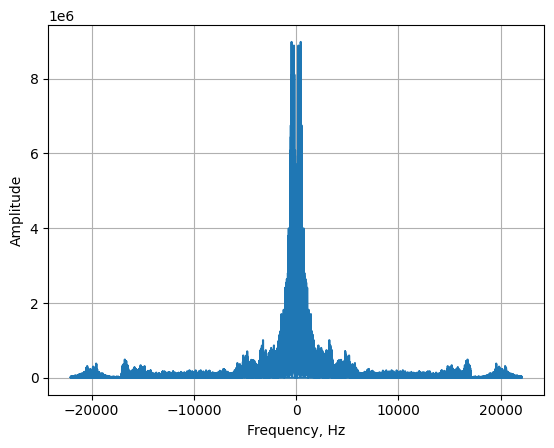

In [ ]:
# спектр отфильтрованного демодулированного сигнала
yf_am = fft(filtered_signal)
xf = fftfreq(N, T)

plt.plot(xf, np.abs(yf_am))
plt.xlabel("Frequency, Hz")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

<h2>Частотно-модулированные (ЧМ) сигналы и фазо-модулированные (ФМ) сигналы</h2>

In [ ]:
def signal_fm(amp=1.0, kd=0.25, fc=10.0, fs=2.0, period=100):
    """
    ----------
    amp : float
        Амплитуда модулирующего сигнала
    kd : float
        Девиация частоты, kd < period/4,
        e.g. fc = 0, fs = 1, kd = 16
    fc : float
        Несущая частота
    fs : float
        Частота модулирующего сигнала
    period : integer
        Период сигнала в отсчетах
    """
    tt = 2.0 * np.pi * np.linspace(0, 1, period)
    return amp * np.cos(fc * tt + kd/fs * np.sin(fs * tt))

Меняем значение девиации частоты. Чем больше девиация по частоте, тем шире спектр сигнала с угловой модуляцией:

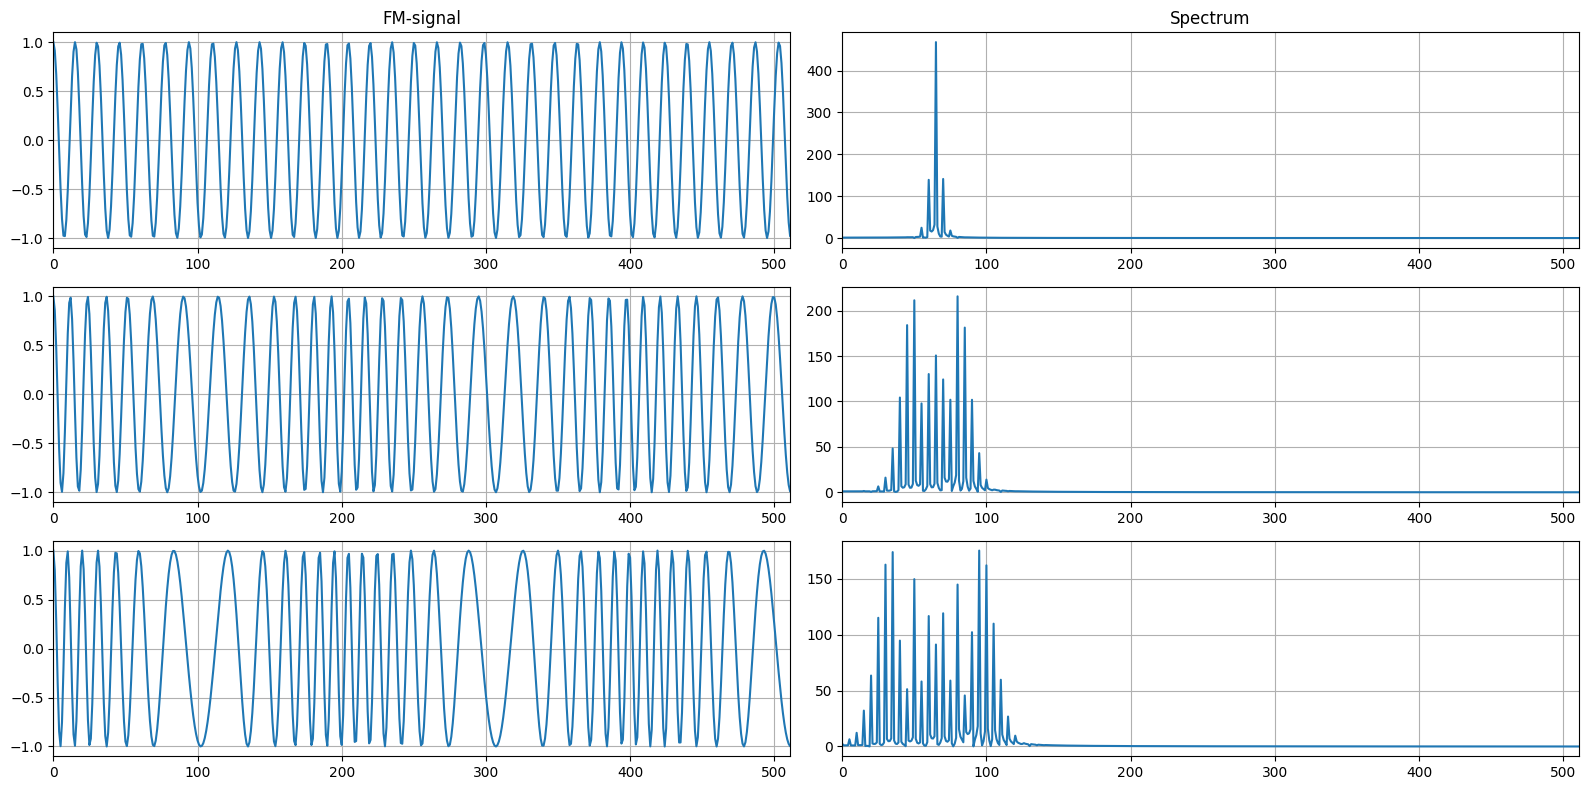

In [ ]:
N = 1024
fs = 5            # Модулирующая частота
fс = 65           # Несущая частота
kd = [3, 23, 40]  # коэффциент модуляции

sig = [signal_fm(amp=1.0, kd=i, fc=fс, fs=fs, period=N) for i in kd]

# Calculate FFT
sft = np.abs(fft(sig, axis=1))

plt.figure(figsize=(16, 8))
for i, freq in enumerate(kd):
    plt.subplot(len(kd), 2, 2*i+1)
    if i == 0:
        plt.title('FM-signal')
    plt.plot(sig[i])
    plt.xlim([0, N//2-1])
    plt.grid(True)

    plt.subplot(len(kd), 2, 2*i+2)
    if i == 0:
        plt.title('Spectrum')
    plt.plot(sft[i])
    plt.xlim([0, N//2-1])
    plt.grid(True)
plt.tight_layout()

Модулирующий и частотно-модулированный сигналы

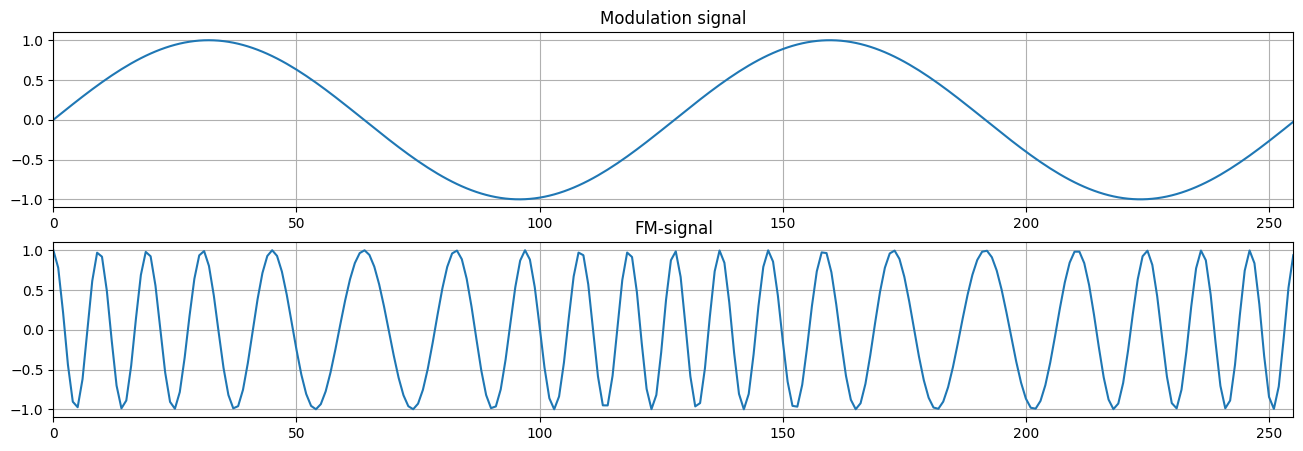

In [ ]:
N = 512
sig = signal_fm(amp=1.0, kd=15, fc=40, fs=4, period=N)
smd = np.sin(4 * 2.0 * np.pi * np.linspace(0, 1, N))

plt.figure(figsize=(16, 5))
plt.subplot(2, 1, 1)
plt.title('Modulation signal')
plt.plot(smd)
plt.xlim([0, N//2-1])
plt.grid(True)

plt.subplot(2, 1, 2)
plt.title('FM-signal')
plt.plot(sig)
plt.xlim([0, N//2-1])
plt.grid(True)